## Experiment 1

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

1) Look at results of the experiments 1 with the sparse function:

Number of episodes: 5


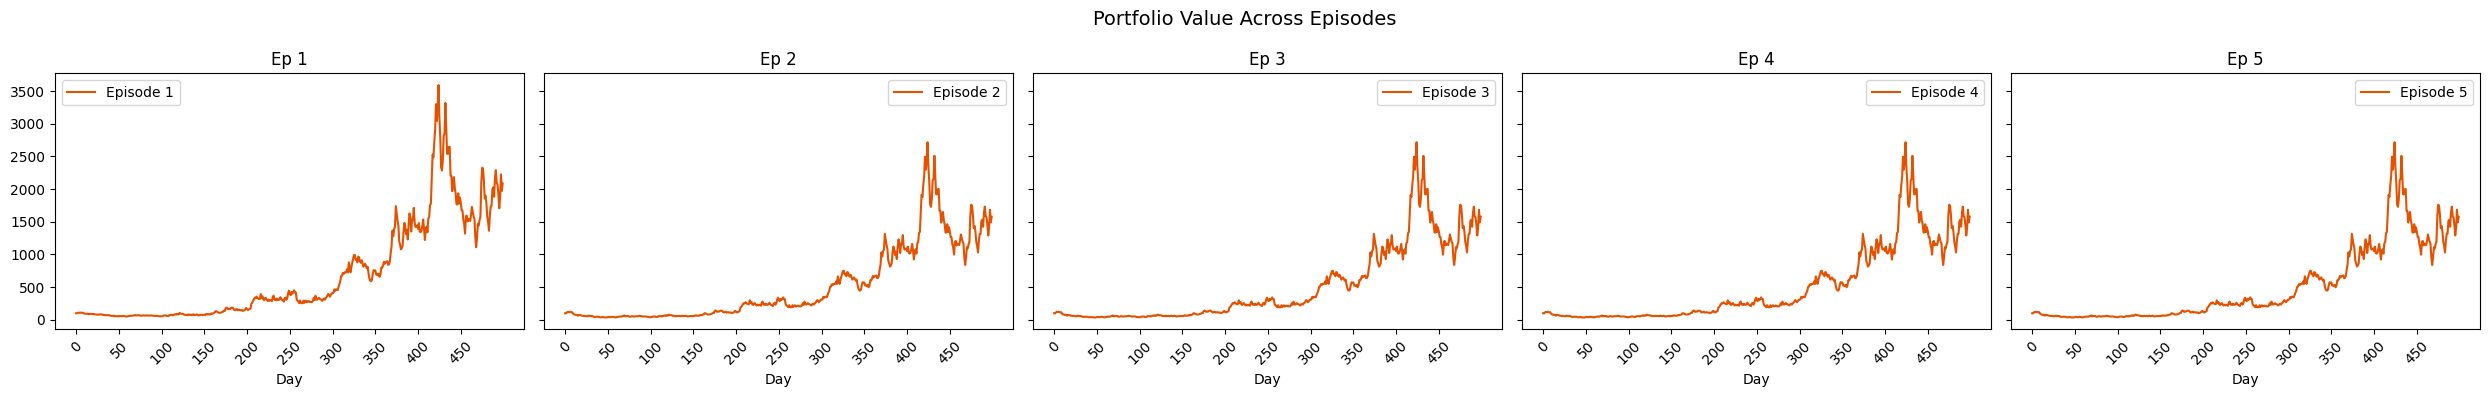

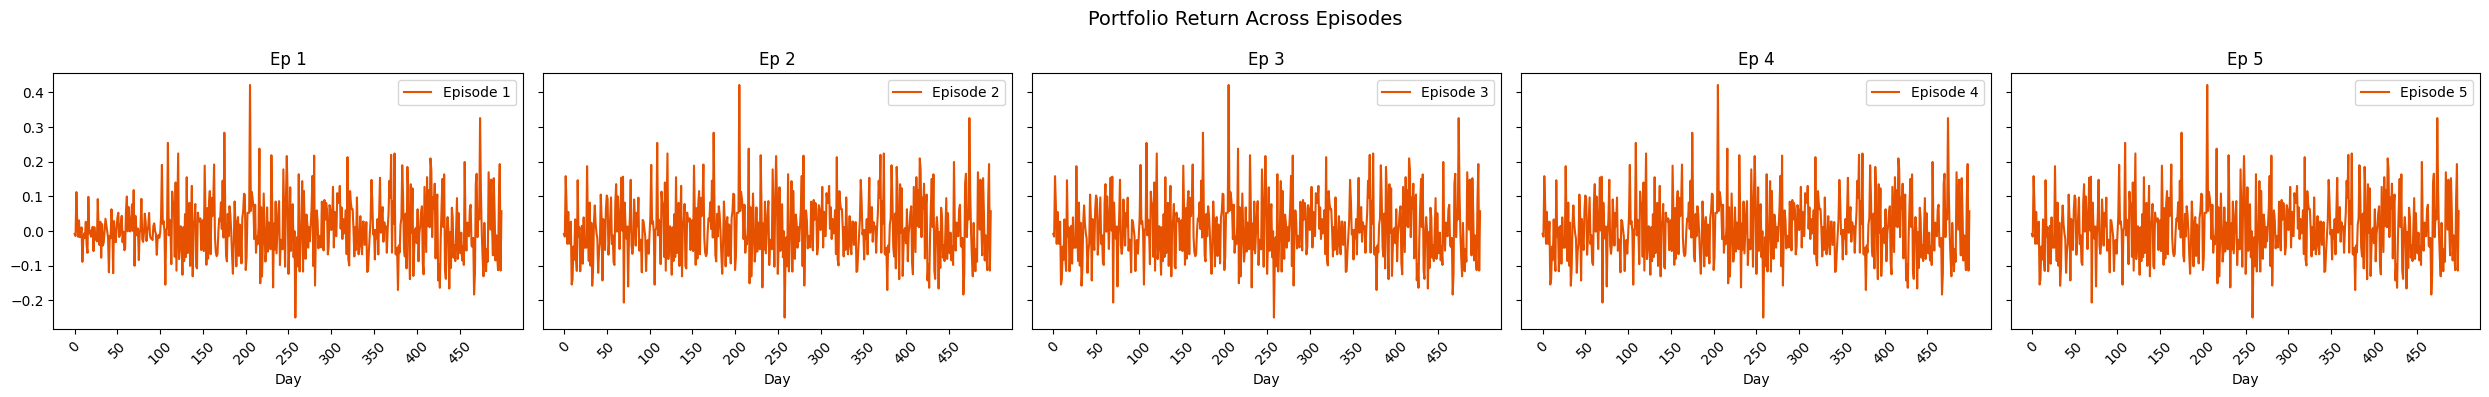

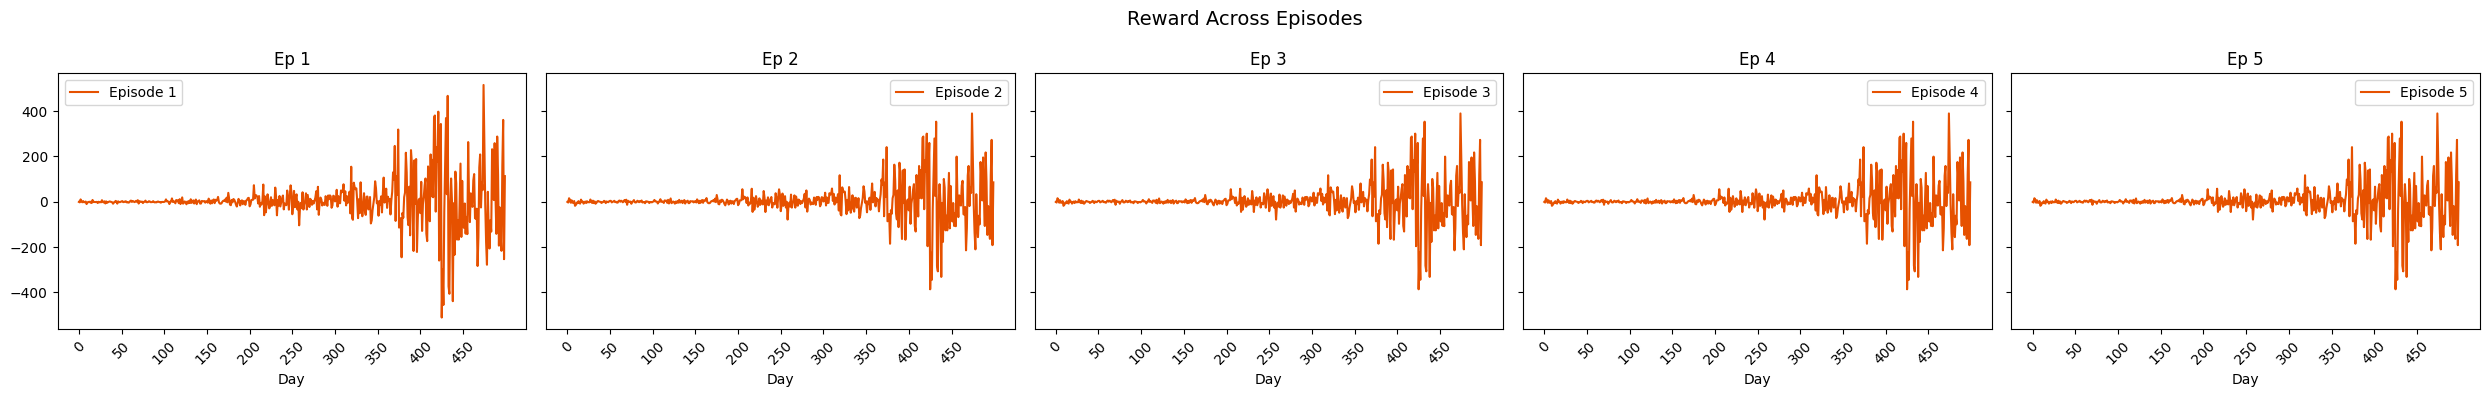

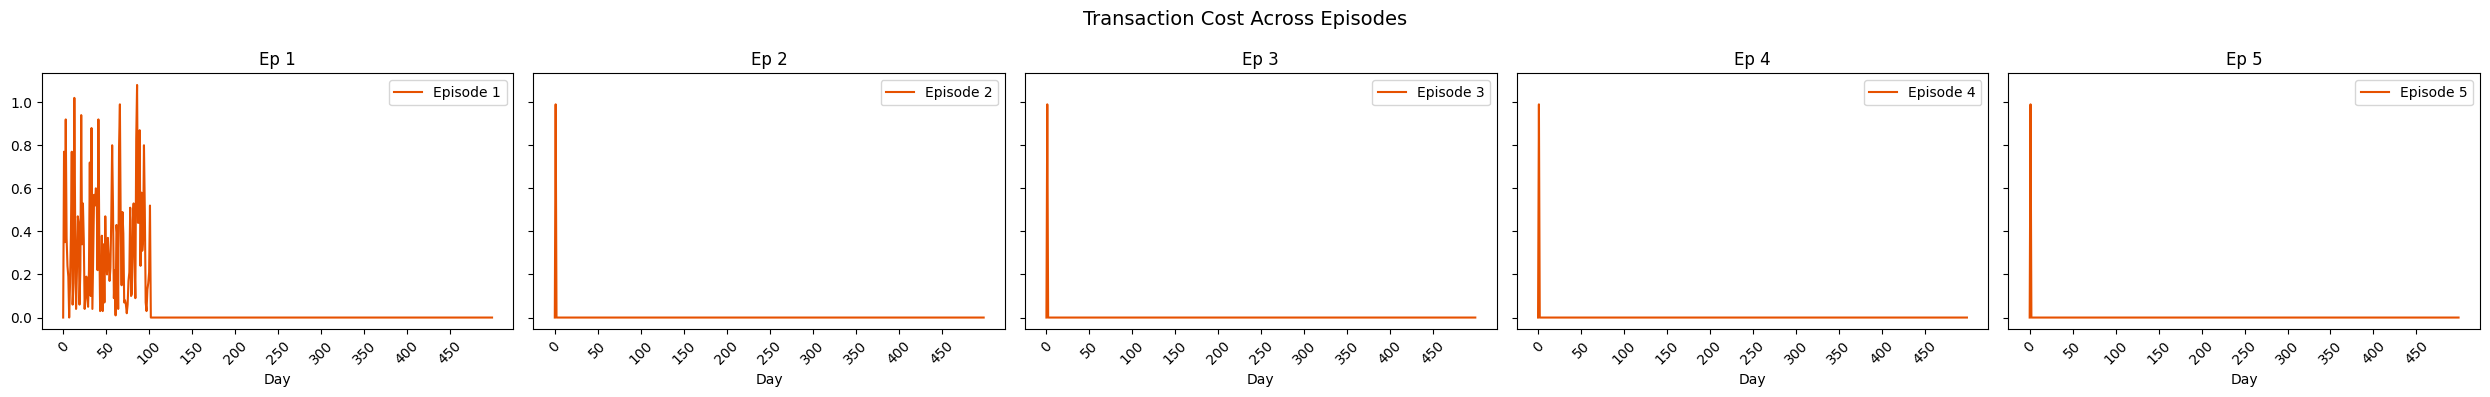

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Load data
reward = "sparse"
df_logs = pd.read_csv(f"Results/Experiment_1/training_logs_{reward}.csv")

# Convert portfolio return to numeric format
df_logs["portfolio_return"] = df_logs["portfolio_return"].str.replace("%", "").astype(float) / 100
# Remove commas before converting new_portfolio_value to float
df_logs["new_portfolio_value"] = df_logs["new_portfolio_value"].str.replace(",", "").astype(float)

# Get unique episodes
episodes = df_logs["episode"].unique()
num_episodes = len(episodes)  # Total number of episodes

# Define function to plot multiple episodes in a single row
def plot_per_episode_row(df, metric, ylabel, title, filename, yticks=5):
    """Plot multiple time series in a single row with separate subplots per episode."""
    fig, axes = plt.subplots(1, num_episodes, figsize=(5 * num_episodes, 4), sharey=True)

    if num_episodes == 1:
        axes = [axes]  # Ensure axes is iterable for a single episode

    for idx, episode in enumerate(episodes):
        df_episode = df[df["episode"] == episode]
        axes[idx].plot(df_episode["day"], df_episode[metric], label=f"Episode {episode}", color="#E65100")

        # Set labels and titles
        axes[idx].set_xlabel("Day")
        axes[idx].set_title(f"Ep {episode}")
        axes[idx].legend()

        # Reduce the number of x-axis ticks
        axes[idx].set_xticks(df_episode["day"][::50])  # Show every 50th day
        axes[idx].tick_params(axis='x', rotation=45)  # Rotate for readability

        # # Reduce the number of y-axis ticks dynamically
        # ymin, ymax = axes[idx].get_ylim()
        # axes[idx].set_yticks(np.linspace(ymin, ymax, yticks))  # Set fixed number of y-ticks

    fig.suptitle(title, fontsize=14)  # Global title
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# **1️⃣ Portfolio Value Plot**
plot_per_episode_row(df_logs, "new_portfolio_value", "Portfolio Value ($)", "Portfolio Value Across Episodes",
                     f"Results/Experiment_1/{reward}_portfolio_value.png", yticks=6)

# **2️⃣ Portfolio Return Plot**
plot_per_episode_row(df_logs, "portfolio_return", "Portfolio Return (%)", "Portfolio Return Across Episodes",
                     f"Results/Experiment_1/{reward}_portfolio_return_row.png", yticks=6)

# **3️⃣ Reward Plot**
plot_per_episode_row(df_logs, "reward", "Reward", "Reward Across Episodes",
                     f"Results/Experiment_1/{reward}_reward_row.png", yticks=6)

# **4️⃣ Transaction Cost Plot**
plot_per_episode_row(df_logs, "transaction_cost", "Transaction Cost ($)", "Transaction Cost Across Episodes",
                     f"Results/Experiment_1/{reward}_transaction_cost_row.png", yticks=6)

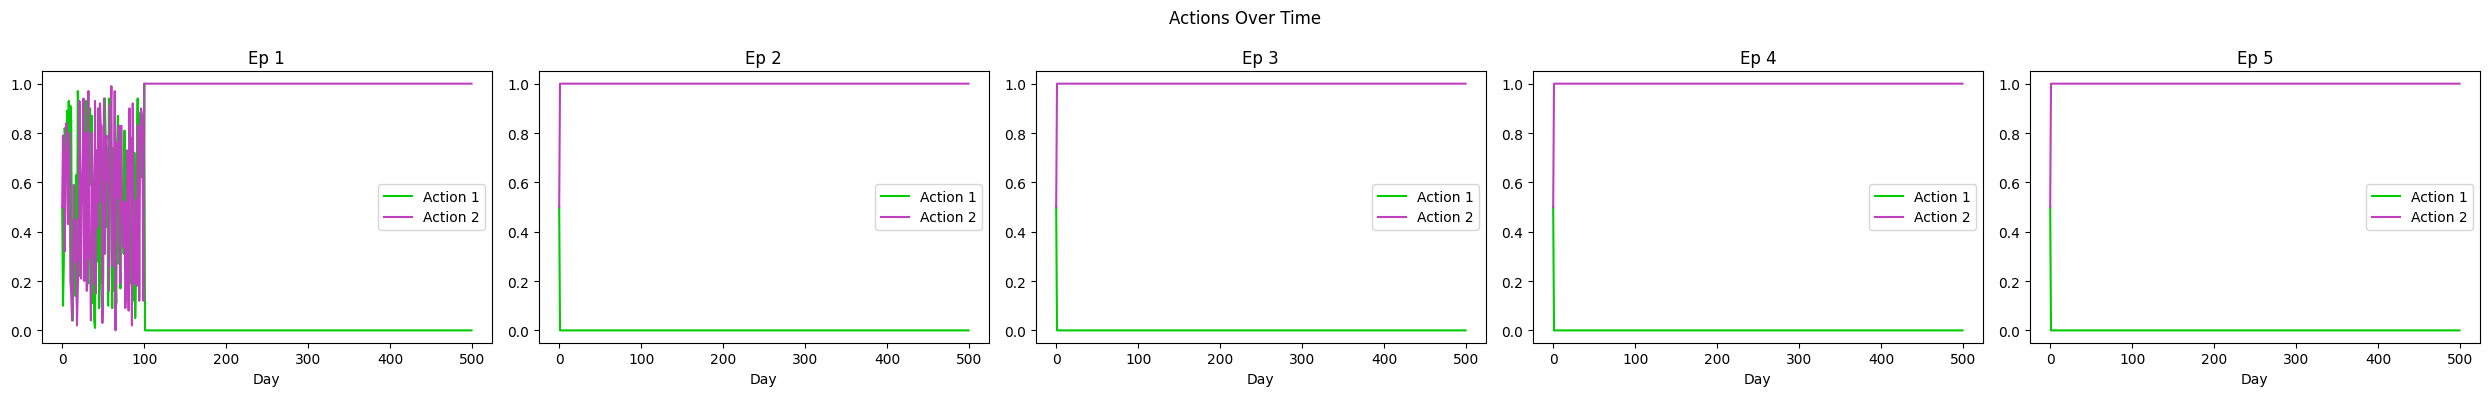

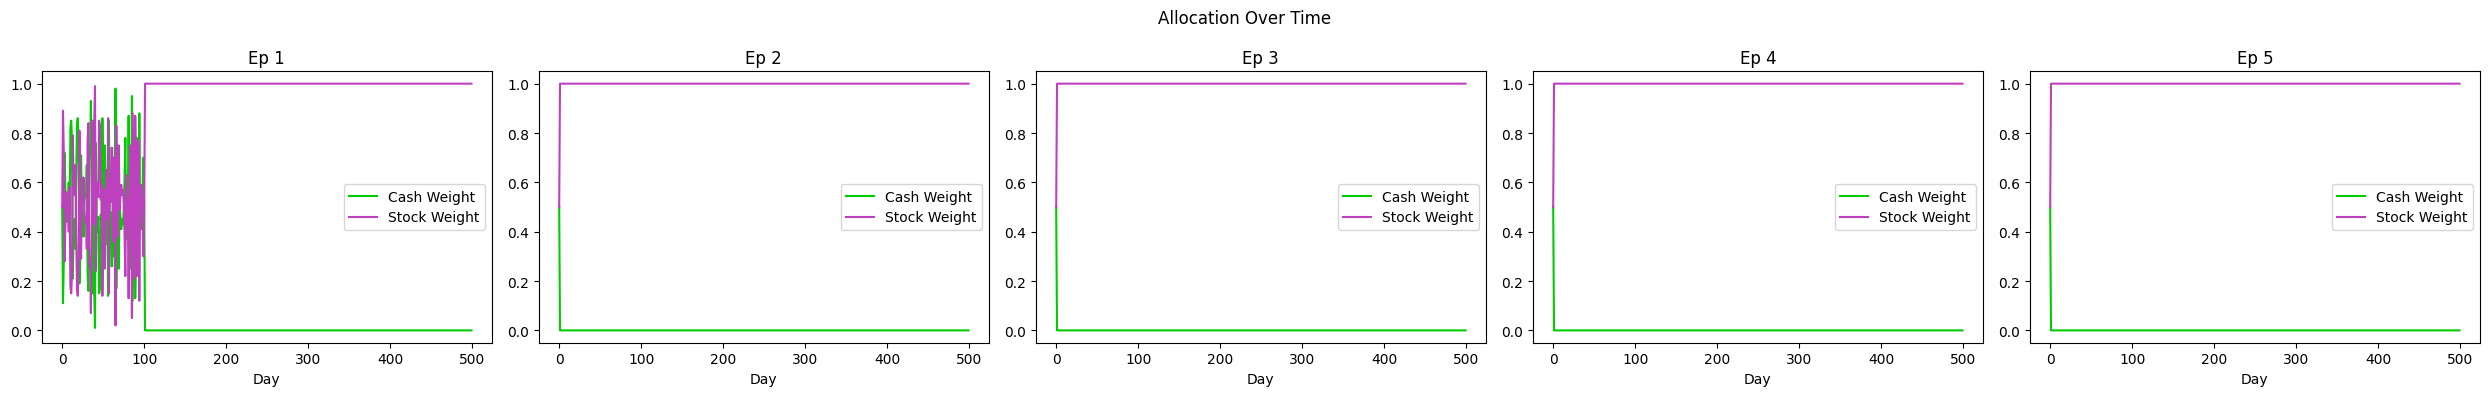

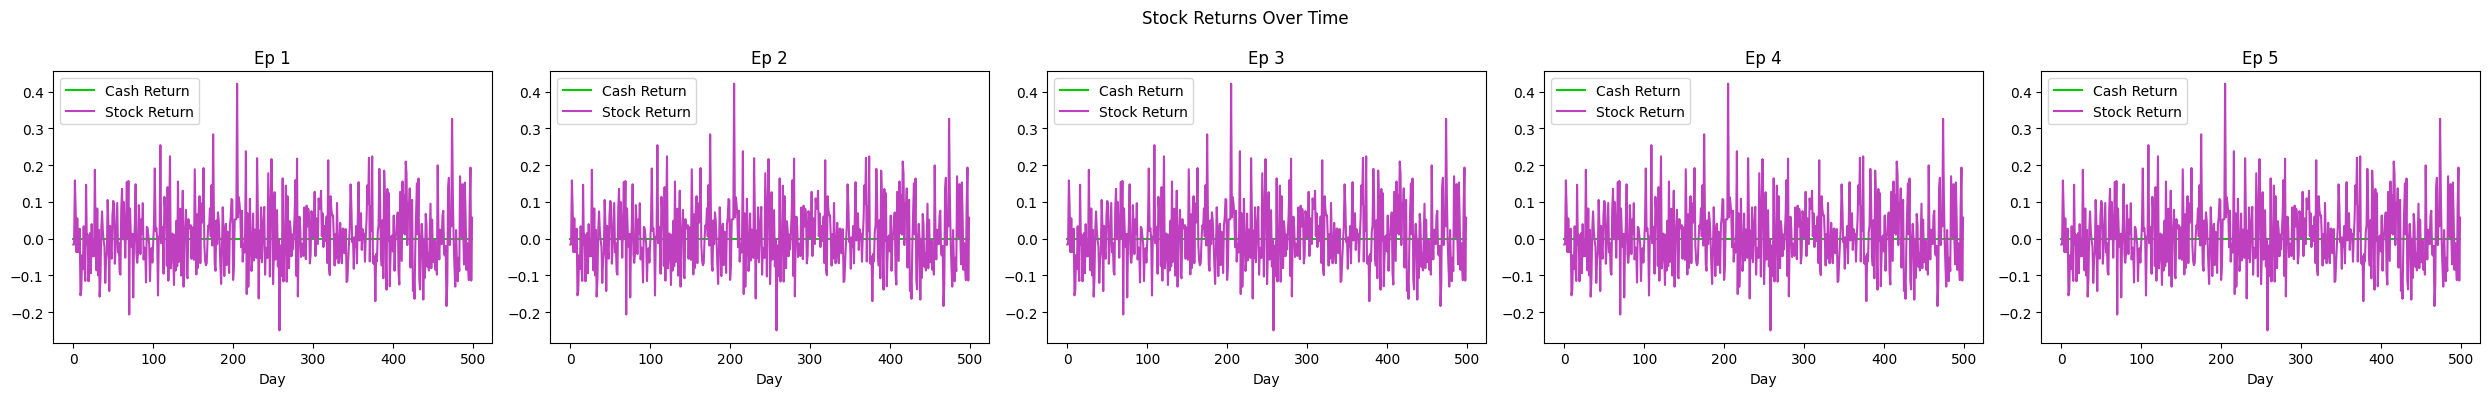

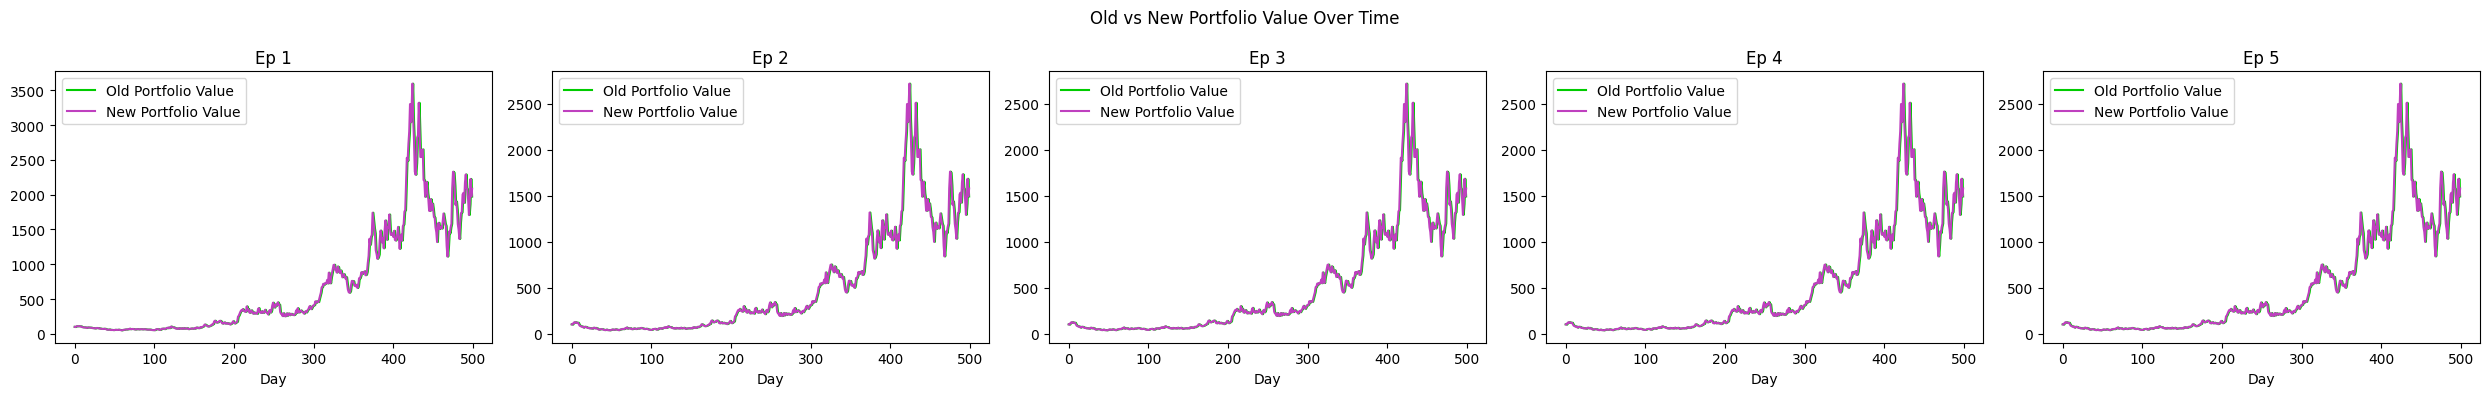

In [36]:
reward = "sparse"
df_logs = pd.read_csv(f"Results/Experiment_1/training_logs_{reward}.csv")

# Convert string columns to lists (for actions, allocation weights, and stock returns)
df_logs["actions"] = df_logs["actions"].apply(lambda x: [float(i) for i in x.strip("[]").split(",")])
df_logs["allocation_weights"] = df_logs["allocation_weights"].apply(lambda x: [float(i) for i in x.strip("[]").split(",")])
df_logs["stock_returns"] = df_logs["stock_returns"].apply(lambda x: [float(i.strip('%')) / 100 for i in x.split(",")])
df_logs["new_portfolio_value"] = df_logs["new_portfolio_value"].str.replace(",", "").astype(float)
df_logs["old_portfolio_value"] = df_logs["old_portfolio_value"].str.replace(",", "").astype(float)
# Define function to plot two lines per subplot per episode
def plot_dual_line_per_episode(df, metric1, metric2, ylabel, title, filename, legend1, legend2):
    """Plot two line graphs in one subplot for each episode."""
    fig, axes = plt.subplots(1, num_episodes, figsize=(5 * num_episodes, 4), sharey=False)

    if num_episodes == 1:
        axes = [axes]  # Ensure axes is iterable for a single episode

    for idx, episode in enumerate(episodes):
        df_episode = df[df["episode"] == episode]
        days = df_episode["day"]
        
        # Extract first and second component (for two-line plots)
        line1 = df_episode[metric1].apply(lambda x: x[0])
        line2 = df_episode[metric2].apply(lambda x: x[1])

        axes[idx].plot(days, line1, label=legend1, color="#00CC00")
        axes[idx].plot(days, line2, label=legend2, color="#BF40BF")
        axes[idx].set_xlabel("Day")
        axes[idx].set_title(f"Ep {episode}")
        axes[idx].legend()

    fig.suptitle(title)  # Global title
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()  # Display the plot

# **1️⃣ Actions Plot**
plot_dual_line_per_episode(df_logs, "actions", "actions", "Actions", 
                           "Actions Over Time", f"Results/Experiment_1/{reward}_actions_plot.png", 
                           legend1="Action 1", legend2="Action 2")

# **2️⃣ Allocation Weights Plot**
plot_dual_line_per_episode(df_logs, "allocation_weights", "allocation_weights", "Allocation Weights", 
                           "Allocation Over Time", f"Results/Experiment_1/{reward}_allocation_plot.png", 
                           legend1="Cash Weight", legend2="Stock Weight")

# **3️⃣ Stock Returns Plot**
plot_dual_line_per_episode(df_logs, "stock_returns", "stock_returns", "Stock Returns (%)", 
                           "Stock Returns Over Time", f"Results/Experiment_1/{reward}_stock_returns_plot.png", 
                           legend1="Cash Return", legend2="Stock Return")

# **4️⃣ Portfolio Value (Old vs New)**
def plot_portfolio_values(df):
    """Plot old vs new portfolio value in separate lines per episode."""
    fig, axes = plt.subplots(1, num_episodes, figsize=(5 * num_episodes, 4), sharey=False)

    if num_episodes == 1:
        axes = [axes]  # Ensure axes is iterable for a single episode

    for idx, episode in enumerate(episodes):
        df_episode = df[df["episode"] == episode]
        days = df_episode["day"]
        
        old_values = df_episode["old_portfolio_value"]
        new_values = df_episode["new_portfolio_value"]

        axes[idx].plot(days, old_values, label="Old Portfolio Value", color="#00CC00")
        axes[idx].plot(days, new_values, label="New Portfolio Value", color="#BF40BF")
        axes[idx].set_xlabel("Day")
        axes[idx].set_title(f"Ep {episode}")
        axes[idx].legend()

    fig.suptitle("Old vs New Portfolio Value Over Time")
    plt.tight_layout()
    plt.savefig("portfolio_value_plot.png")
    plt.show()

# **5️⃣ Old vs New Portfolio Value Plot**
plot_portfolio_values(df_logs)